# Illustrator agent

Given raw text our autonomous agent will:

- Read the article and analyze its topic and structure.
- Decide how many images suit better to the article. Focusing on improving attractiveness while not harming readability.
- Decide where in the article new companion images should be located.
- Create detailed image descriptions suitable to create suggested images using an external image generator model.

In [1]:
import os
import json

from crewai import LLM, Agent, Task, Crew, Process
from dotenv import load_dotenv

from IPython.display import Image

# Configure LLMs and providers

In [ ]:
SELECTED_MODEL="deepseek/deepseek-v4-flash-0731"
URL_PROVIDER="https://openrouter.ai/api/v1/chat/completions"
DESIRED_REASONING_EFFORT="none"

# https://api-docs.deepseek.com/guides/thinking_mode/

In [3]:
load_dotenv(override=True)

True

In [4]:
API_KEY = os.getenv("API_KEY")

In [ ]:
def get_llm():
    return LLM(model=SELECTED_MODEL, 
               api_key=API_KEY, 
               base_url=URL_PROVIDER,
               reasoning_effort=DESIRED_REASONING_EFFORT,
               )

In [6]:
llm = get_llm()

# General structure of a Crew AI agent

1. Agents
2. Tasks
3. Crew

## 1. Agents

In [7]:
image_creator_agent = Agent(
    role="Senior image creator",
    goal="To generate high-quality image descriptions that align with the content of articles.",
    backstory="You have been analyzing articles for years and know how to create compelling images that capture the essence of the content and increase reader engagement. "
                "You are skilled in understanding the nuances of different topics and can generate image descriptions that are both relevant and engaging.",
    tools=[],
    verbose=True,
    llm=llm
    )

## 2. Tasks

In [8]:
image_creator_task = Task(
    name="Image description generation",
    description="You will generate good quality image descriptions for an article. "
                "Depending on the topic and the length of the article you will decide the number of images. Always between 1 and 3. "
                "This is the article content: {article_content}",
    expected_output="""A list containing JSON objects, each one with 3 keys: 
                    'order' which contains an integer that indicates the order (1,2 ..) of the generated image. 
                    'previous_text': last 4 or 5 words where you decide to insert the image below, just for position reference. 
                    'description': a very detailed image description that can be used to create the image.""",
    context=[],
    agent=image_creator_agent
)

## 3. Crew

In [9]:
crew = Crew(agents=[image_creator_agent],
            tasks=[image_creator_task],
            process=Process.sequential,
            verbose=True)

Configure the crew, i.e. complete variables

In [10]:
# URL: https://www.xataka.com/medicina-y-salud/cantidad-cafeina-bebidas-que-consumimos-a-diario-expuesta-este-grafico

article_content = \
"""
La cantidad de cafeína de las bebidas que consumimos a diario, expuesta en este gráfico
Alejandro Alcolea
5-6 minutos

La cafeína es una de las sustancias más consumidas en el mundo. Se estima que cerca del 80% de la población mundial consume cafeína a diario y, aunque el café es una importante fuente, también está presente en el té, el café, la yerba mate, las vainas de cacao o en la nuez de kola -ingrediente de la Coca-Cola original-. Sin embargo, también se puede producir de forma sintética para añadirla a refrescos, bebidas energéticas o suplementos.

Y en este gráfico elaborado por Visual Capitalist, podemos ver cuánta cafeína tienen las bebidas que consumimos constantemente.

Cafeína de bebidas

El gráfico. Elaborado con datos de EFSA (la Autoridad Europea de Seguridad Alimentaria, en castellano) tras encuestar a más de 66.500 personas de 22 países europeos, el gráfico es bastante autoexplicativo. En algunas publicaciones de este tipo se suele obviar la marca, pero lo realmente útil de este gráfico es que, directamente, se indica la cantidad de cafeína en bebidas comerciales como Monster, Red Bull o Prime (una marca creada por el polémico Logan Paul).

También es útil que se ofrecen tanto los miligramos de cafeína de las bebidas como la cantidad de líquido que consumimos, ya que así podemos calcular de forma más efectiva “cuántos Red Bull puedo tomar para tener una dosis segura”. Un Monster es lo que más cafeína tiene, pero también porque la muestra es de medio litro. Prime, con menos cantidad (330 ml), está cerca de la cafeína de un Monster con sus 140 mg. Y es curioso que la bebida que nos da alas tenga en un bote la misma cantidad que un espresso doble: 80 mg.

No me gusta el café, pero tras repasar lo que dice la ciencia he empezado a consumirlo diariamente

No sólo cafeína. Lo que ocurre con las bebidas energéticas es que, como la propia EFSA detalla, el estimulante que contienen no se limita a la cafeína. Aparte de ese compuesto, tienen otros ingredientes como la taurina o el D-gucorono-y-lactona. La taurina es un aminoácido que participa en el control del calcio celular y la función cardíaca, asociado con la mejora de la resistencia deportiva al permitir mantener altos esfuerzos durante más tiempo, reduciendo la fatiga.

El D-glucurono-y-lactona es un metabolito del glucurónico que ayuda en la síntesis de la vitamina C, y ambos son seguros por su rápida metabolización, pese a que pueden tener efectos segundarios como algunas molestias digestivas en consumos altos. Y si la cafeína, la taurina y el D-glucurono-γ-lactona fueran poco, al cóctel hay que añadir algo más perjudicial: enormes cantidades de azúcar en estas bebidas energéticas.

Consumo por edades. La EFSA ha creado una tabla que indica cuántos mg de cafeína consumimos a diario dependiendo de nuestra edad:

rango de edad
	

Consumo diario

A partir de 75 años
	

22-417 mg

Entre 65 y 75 años
	

23-362 mg

entre 18 y 65 años
	

37-319 mg

entre 10 y 18 años
	

0,4-1,4 mg/kg

entre 3 y 10 años
	

0,2-2,0 mg/kg

entre 12 y 36 meses
	

0-2,1 mg/kg

Entre los adultos, el café es la fuente más importante de cafeína, representando entre el 40% y el 94% de la ingesta total diaria. En Irlanda y Reino Unido, la cosa cambia, y esa fuente principal es el té, representando entre el 59% y el 57% de la ingesta, respectivamente. Entre los adolescentes, la principal fuente de cafeína es el chocolate (tanto en barra como en bebidas de cacao), seguido del café, las bebidas de cola y el té. Y de 10 años para abajo, el café desaparece y el chocolate sigue reinando, seguido del té y de las bebidas de cola.

Hubo un tiempo en que la Coca-Cola tenía 'cocaína'. Que ya no la tenga se debe a algo sorprendente: el racismo

Consumo seguro, pero con asteriscos. Una de las cuestiones que sigue preocupando a quien busca cuidarse es cuánta cafeína es mucha cafeína. Los 400 mg al día se han tomado como la medida universal para decir que es la cantidad “segura”, pero es algo que depende de varios factores. Por ejemplo, dosis únicas de cafeína de hasta 200 mg no presentan problemas de seguridad para la población adulta sana general.

Pero si eres una mujer y estás embarazada, esa cifra segura baja hasta los 200 mg al día, repartidos a lo largo de la jornada. Además, si se consumen dosis únicas de 100 mg antes de irnos a dormir, se puede alterar el patrón de calidad de sueño, pero es algo que no ocurre en todos los adultos.

Pero claro, todo depende de un término clave: población sana, ya que hay estudios que relacionan la cafeína con efectos negativos en fases de restricción crónica del sueño y, si bien se utiliza como estimulante en la práctica deportiva, sus efectos serán más o menos beneficiosos dependiendo del deporte que practiquemos o las decisiones que debamos tomar.
"""

In [11]:
crew_config = {"article_content": article_content}

## Launch execution

In [12]:
result = crew.kickoff(crew_config)

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 6b5d944b-943f-419e-b252-dc37a8513ca2                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior image creator                                                                                    │
│                                                                                                                 │
│  Task: You will generate good quality image descriptions for an article. Depending on the topic and the length  │
│  of the article you will decide the number of images. Always between 1 and 3. This is the article content:      │
│  La cantidad de cafeína de las bebidas que consumimos a diario, expuesta en este gráfico                        │
│  Alejandro Alcolea                                                                                              │
│  5-6 minutos                                                                                                    │
│                                                                                                                 │
│  La cafeína es una de las sustancias más consumidas en el mundo. Se estima que cerca del 80% de la población    │
│  mundial consume cafeína a diario y, aunque el café es una importante fuente, también está presente en el té,   │
│  el café, la yerba mate, las vainas de cacao o en la nuez de kola -ingrediente de la Coca-Cola original-. Sin   │
│  embargo, también se puede producir de forma sintética para añadirla a refrescos, bebidas energéticas o         │
│  suplementos.                                                                                                   │
│                                                                                                                 │
│  Y en este gráfico elaborado por Visual Capitalist, podemos ver cuánta cafeína tienen las bebidas que           │
│  consumimos constantemente.                                                                                     │
│                                                                                                                 │
│  Cafeína de bebidas                                                                                             │
│                                                                                                                 │
│  El gráfico. Elaborado con datos de EFSA (la Autoridad Europea de Seguridad Alimentaria, en castellano) tras    │
│  encuestar a más de 66.500 personas de 22 países europeos, el gráfico es bastante autoexplicativo. En algunas   │
│  publicaciones de este tipo se suele obviar la marca, pero lo realmente útil de este gráfico es que,            │
│  directamente, se indica la cantidad de cafeína en bebidas comerciales como Monster, Red Bull o Prime (una      │
│  marca creada por el polémico Logan Paul).                                                                      │
│                                                                                                                 │
│  También es útil que se ofrecen tanto los miligramos de cafeína de las bebidas como la cantidad de líquido que  │
│  consumimos, ya que así podemos calcular de forma más efectiva “cuántos Red Bull puedo tomar para tener una     │
│  dosis segura”. Un Monster es lo que más cafeína tiene, pero también porque la muestra es de medio litro.       │
│  Prime, con menos cantidad (330 ml), está cerca de la cafeína de un Monster con sus 140 mg. Y es curioso que    │
│  la bebida que nos da alas tenga en un bote la misma cantidad que un espresso doble: 80 mg.                     │
│                                                                                                                 │
│  No me gusta el café, pero tras repasar lo que dice la ciencia he empezado a consumirlo diariamente             │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior image creator                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  [                                                                                                              │
│    {                                                                                                            │
│      "order": 1,                                                                                                │
│      "previous_text": "las bebidas que consumimos constantemente.",                                             │
│      "description": "Infografía vectorial moderna y limpia sobre fondo blanco, estilo editorial. En la parte    │
│  superior, un título grande: '¿Cuánta cafeína tiene tu bebida?' acompañado de un icono de taza de café          │
│  humeante y granos de café. Debajo, un gráfico de barras horizontales ordenado de mayor a menor cantidad de     │
│  cafeína, con tarjetas redondeadas de colores. Aparecen representadas una lata negra y verde de bebida          │
│  energética tipo Monster (500 ml, 160 mg), una lata rosa y blanca tipo Prime (330 ml, 140 mg), una taza de      │
│  café filtrado (200 ml, 90 mg), una lata azul y plateada tipo Red Bull (250 ml, 80 mg), un espresso doble en    │
│  taza pequeña (60 ml, 80 mg), una botella de refresco de cola (330 ml, 32 mg) y una taza de té negro (220 ml,   │
│  50 mg). Cada barra incluye el nombre de la bebida, el volumen en mililitros y la cantidad de cafeína en        │
│  miligramos dentro de un recuadro destacado. Al final de cada barra hay pequeños iconos de tazas o personas     │
│  para comparar visualmente la cantidad. Estilo flat, paleta de colores cálidos y frescos, tipografía            │
│  sans-serif legible y composición muy ordenada."                                                                │
│    },                                                                                                           │
│    {                                                                                                            │
│      "order": 2,                                                                                                │
│      "previous_text": "azúcar en estas bebidas energéticas.",                                                   │
│      "description": "Ilustración conceptual y didáctica sobre el contenido real de las bebidas energéticas. En  │
│  el centro hay una lata de bebida energética de colores llamativos, con gotas de condensación y destellos       │
│  brillantes, rodeada por una explosión de ingredientes: una molécula de cafeína con su estructura química, un   │
│  montón de cubos de azúcar cayendo desde la parte superior, una cápsula o polvo de taurina y un pequeño frasco  │
│  con la etiqueta 'D-glucurono-γ-lactona'. Alrededor aparecen iconos temáticos: un corazón con línea de latido,  │
│  una luna con estrellas para representar el sueño, una cuchara con azúcar y un rayo de energía. El fondo es un  │
│  degradado oscuro de azul marino a púrpura, con luces de neón y estilo flat con algunos reflejos brillantes.    │
│  En la parte superior se lee el texto grande 'No es solo cafeína' y en la parte inferior hay una franja de      │
│  advertencia con la frase 'Alto contenido de azúcar'. La composición es dinámica, con colores intensos y        │
│  elementos claramente separados para que sea fácil de entender."                                                │
│    },                                                  

╭──────────────────────────────────────────────── Task Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Image description generation                                                                             │
│  Agent: Senior image creator                                                                                    │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 6b5d944b-943f-419e-b252-dc37a8513ca2                                                                       │
│  Tool Args:                                                                                                     │
│  Final Output: [                                                                                                │
│    {                                                                                                            │
│      "order": 1,                                                                                                │
│      "previous_text": "las bebidas que consumimos constantemente.",                                             │
│      "description": "Infografía vectorial moderna y limpia sobre fondo blanco, estilo editorial. En la parte    │
│  superior, un título grande: '¿Cuánta cafeína tiene tu bebida?' acompañado de un icono de taza de café          │
│  humeante y granos de café. Debajo, un gráfico de barras horizontales ordenado de mayor a menor cantidad de     │
│  cafeína, con tarjetas redondeadas de colores. Aparecen representadas una lata negra y verde de bebida          │
│  energética tipo Monster (500 ml, 160 mg), una lata rosa y blanca tipo Prime (330 ml, 140 mg), una taza de      │
│  café filtrado (200 ml, 90 mg), una lata azul y plateada tipo Red Bull (250 ml, 80 mg), un espresso doble en    │
│  taza pequeña (60 ml, 80 mg), una botella de refresco de cola (330 ml, 32 mg) y una taza de té negro (220 ml,   │
│  50 mg). Cada barra incluye el nombre de la bebida, el volumen en mililitros y la cantidad de cafeína en        │
│  miligramos dentro de un recuadro destacado. Al final de cada barra hay pequeños iconos de tazas o personas     │
│  para comparar visualmente la cantidad. Estilo flat, paleta de colores cálidos y frescos, tipografía            │
│  sans-serif legible y composición muy ordenada."                                                                │
│    },                                                                                                           │
│    {                                                                                                            │
│      "order": 2,                                                                                                │
│      "previous_text": "azúcar en estas bebidas energéticas.",                                                   │
│      "description": "Ilustración conceptual y didáctica sobre el contenido real de las bebidas energéticas. En  │
│  el centro hay una lata de bebida energética de colores llamativos, con gotas de condensación y destellos       │
│  brillantes, rodeada por una explosión de ingredientes: una molécula de cafeína con su estructura química, un   │
│  montón de cubos de azúcar cayendo desde la parte superior, una cápsula o polvo de taurina y un pequeño frasco  │
│  con la etiqueta 'D-glucurono-γ-lactona'. Alrededor aparecen iconos temáticos: un corazón con línea de latido,  │
│  una luna con estrellas para representar el sueño, una cuchara con azúcar y un rayo de energía. El fondo es un  │
│  degradado oscuro de azul marino a púrpura, con luces de neón y estilo flat con algunos reflejos brillantes.    │
│  En la parte superior se lee el texto grande 'No es solo cafeína' y en la parte inferior hay una franja de      │
│  advertencia con la frase 'Alto contenido de azúcar'. La composición es dinámica, con colores intensos y        │
│  elementos claramente separados para que sea fácil de 

## Results

In [13]:
print(result.raw)

[
  {
    "order": 1,
    "previous_text": "las bebidas que consumimos constantemente.",
    "description": "Infografía vectorial moderna y limpia sobre fondo blanco, estilo editorial. En la parte superior, un título grande: '¿Cuánta cafeína tiene tu bebida?' acompañado de un icono de taza de café humeante y granos de café. Debajo, un gráfico de barras horizontales ordenado de mayor a menor cantidad de cafeína, con tarjetas redondeadas de colores. Aparecen representadas una lata negra y verde de bebida energética tipo Monster (500 ml, 160 mg), una lata rosa y blanca tipo Prime (330 ml, 140 mg), una taza de café filtrado (200 ml, 90 mg), una lata azul y plateada tipo Red Bull (250 ml, 80 mg), un espresso doble en taza pequeña (60 ml, 80 mg), una botella de refresco de cola (330 ml, 32 mg) y una taza de té negro (220 ml, 50 mg). Cada barra incluye el nombre de la bebida, el volumen en mililitros y la cantidad de cafeína en miligramos dentro de un recuadro destacado. Al final de cada barr

## Costs

In [14]:
crew.usage_metrics

UsageMetrics(total_tokens=7821, prompt_tokens=1684, cached_prompt_tokens=0, completion_tokens=6137, successful_requests=1)

# Let's visualize the results

https://aistudio.google.com

Model: Nano Banana

In [15]:
result_json = json.loads(result.raw)

## Image 1

In [16]:
print(result_json[0]['description'])

Infografía vectorial moderna y limpia sobre fondo blanco, estilo editorial. En la parte superior, un título grande: '¿Cuánta cafeína tiene tu bebida?' acompañado de un icono de taza de café humeante y granos de café. Debajo, un gráfico de barras horizontales ordenado de mayor a menor cantidad de cafeína, con tarjetas redondeadas de colores. Aparecen representadas una lata negra y verde de bebida energética tipo Monster (500 ml, 160 mg), una lata rosa y blanca tipo Prime (330 ml, 140 mg), una taza de café filtrado (200 ml, 90 mg), una lata azul y plateada tipo Red Bull (250 ml, 80 mg), un espresso doble en taza pequeña (60 ml, 80 mg), una botella de refresco de cola (330 ml, 32 mg) y una taza de té negro (220 ml, 50 mg). Cada barra incluye el nombre de la bebida, el volumen en mililitros y la cantidad de cafeína en miligramos dentro de un recuadro destacado. Al final de cada barra hay pequeños iconos de tazas o personas para comparar visualmente la cantidad. Estilo flat, paleta de color

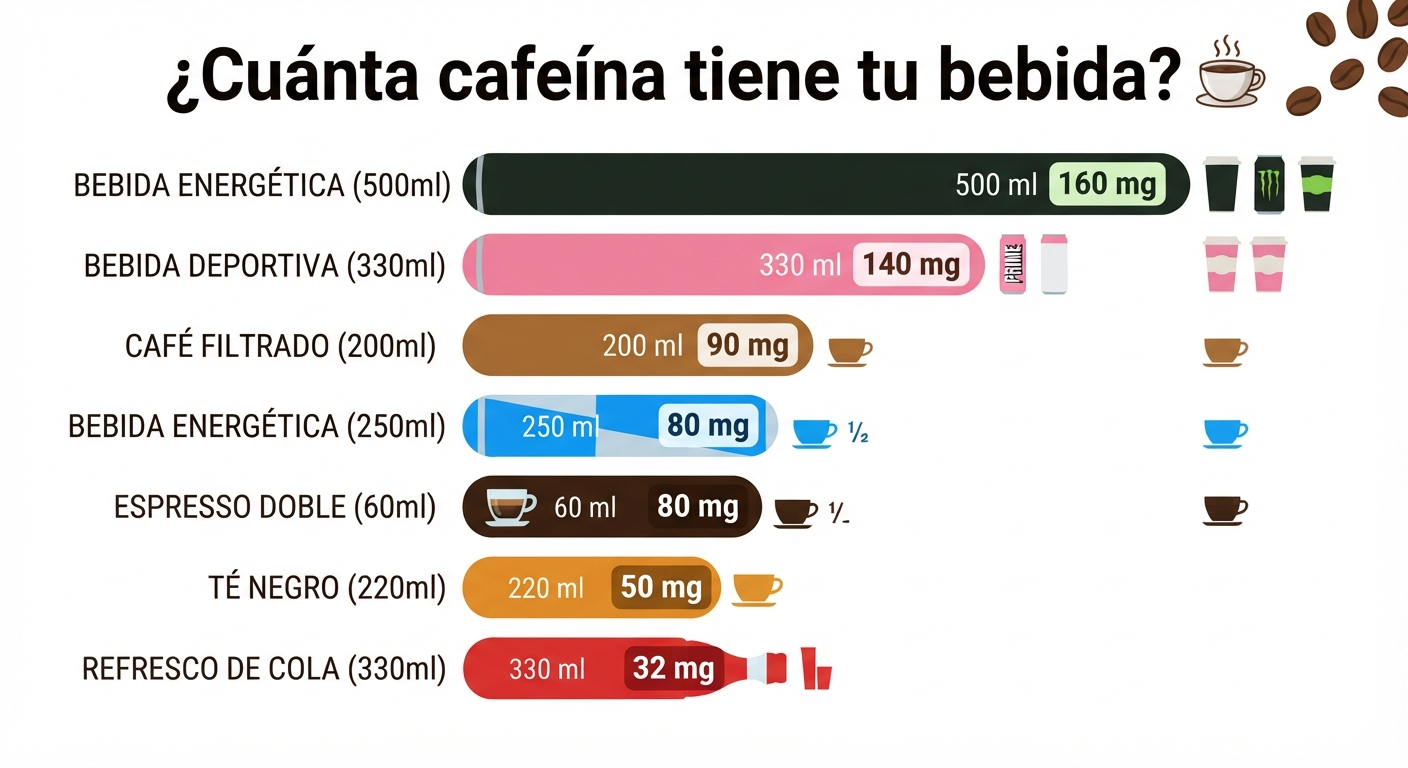

In [23]:
Image(filename="../../resources/generated1.jpg", retina=True)

## Image 2

In [18]:
print(result_json[1]['description'])

Ilustración conceptual y didáctica sobre el contenido real de las bebidas energéticas. En el centro hay una lata de bebida energética de colores llamativos, con gotas de condensación y destellos brillantes, rodeada por una explosión de ingredientes: una molécula de cafeína con su estructura química, un montón de cubos de azúcar cayendo desde la parte superior, una cápsula o polvo de taurina y un pequeño frasco con la etiqueta 'D-glucurono-γ-lactona'. Alrededor aparecen iconos temáticos: un corazón con línea de latido, una luna con estrellas para representar el sueño, una cuchara con azúcar y un rayo de energía. El fondo es un degradado oscuro de azul marino a púrpura, con luces de neón y estilo flat con algunos reflejos brillantes. En la parte superior se lee el texto grande 'No es solo cafeína' y en la parte inferior hay una franja de advertencia con la frase 'Alto contenido de azúcar'. La composición es dinámica, con colores intensos y elementos claramente separados para que sea fáci

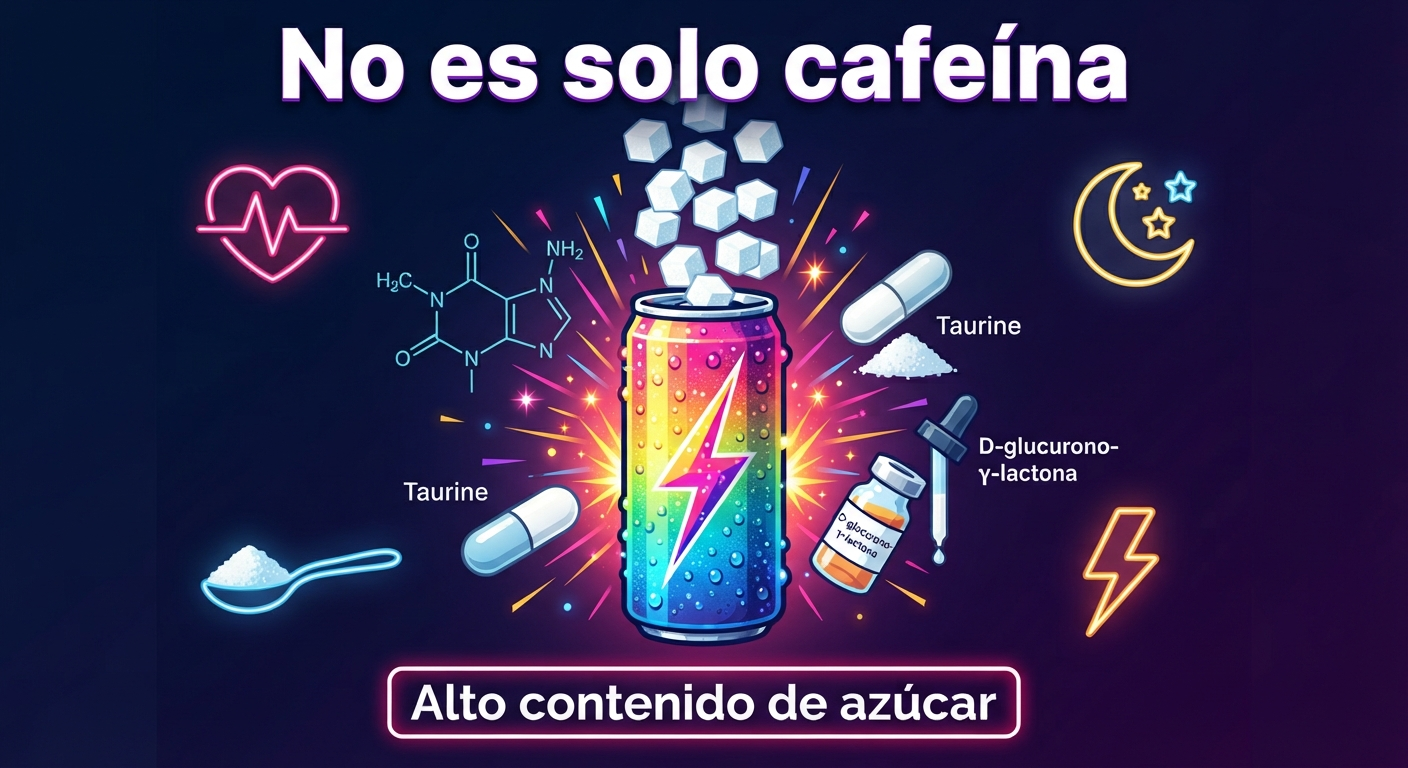

In [24]:
Image(filename="../../resources/generated2.jpg", retina=True)

## Image 3

In [20]:
print(result_json[2]['description'])

Infografía educativa dividida en dos paneles horizontales sobre fondo blanco. El panel izquierdo muestra una tabla visual de consumo diario de cafeína por rangos de edad, con filas de colores y siluetas humanas representando cada etapa: '12-36 meses: 0-2,1 mg/kg', '3-10 años: 0,2-2,0 mg/kg', '10-18 años: 0,4-1,4 mg/kg', '18-65 años: 37-319 mg', '65-75 años: 23-362 mg' y 'A partir de 75 años: 22-417 mg'. Cada fila tiene un icono de bebé, niño, adolescente, adulto y persona mayor, con barras horizontales que indican la cantidad. El panel derecho ilustra las principales fuentes de cafeína según la edad: una taza de café humeante, una taza de té, una tableta de chocolate, una botella de refresco de cola y una taza de cacao. Debajo de cada icono aparecen leyendas con porcentajes y datos, como 'café: 40%-94% en adultos', 'té: 59% en Irlanda y 57% en Reino Unido', 'chocolate: principal fuente en adolescentes y niños'. El estilo es flat, limpio y educativo, con tarjetas de esquinas redondeadas

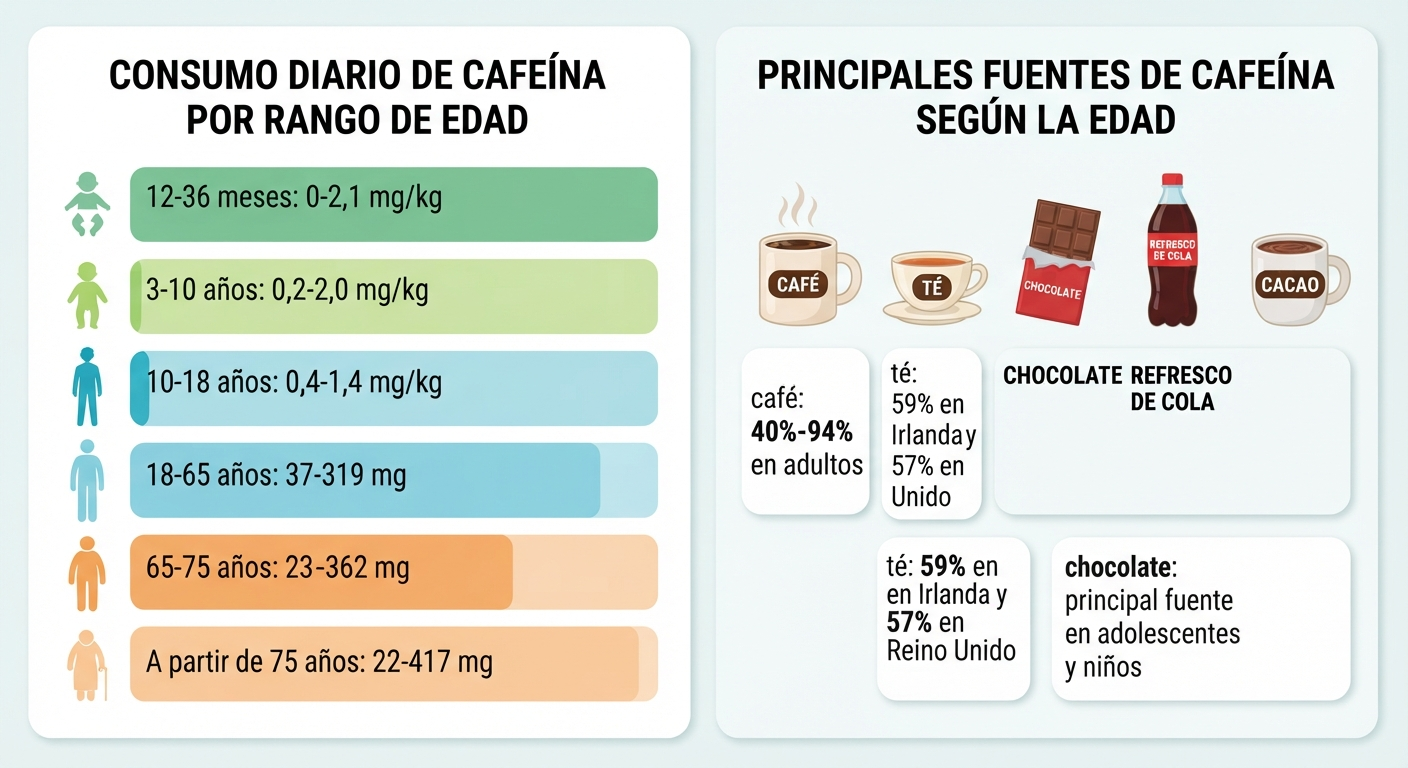

In [25]:
Image(filename="../../resources/generated3.jpg", retina=True)

# Improvements

- Images:
  - Less charts, less scientific, more companion, illustration. 
  - Tailored to the audience (topic, age, country) and the device (mobile, computer).
  
- Why manual interconnection?
  - Monitor a shared folder. Thus when our community manager writes the article and send it to us in Dropbox we can trigger the agent's crew to automatically read the content and start the processing.
  - Use generated image descriptions to call an API to create the image and retrieve it from code.
  - Instead of manually inserting the image, generate the final document with images inserted in the correct place


Key takeaways

- **Integration is the key my friend!!**
- Robustness in production is extremely important.
  - LLM may hallucinate (or troll you as I prefer to say)
  - 3º party services can behave in different ways as you expect (read documentation cough cough): image models may block specific brands or celebrities